In [1]:
import torch
import torch.nn.functional as F

from datasets import load_from_disk
from pathlib import Path
from typing import Dict

from config import Config
from data_utils import generate_causal_mask
from pipeline import get_dataloaders
from transformer.transformer_model import TransformerNMT, TransformerConfig
from tqdm import tqdm
import re
from typing import List, Tuple
import sacrebleu
import matplotlib.pyplot as plt


c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = Path("parallel_en_fr_corpus")
batch_size = 32
epochs = 10
lr = 1e-3
save_dir = "checkpoints"

cfg = TransformerConfig(
    d_model=32,
    n_heads=4,
    n_encoder_layers=3,
    n_decoder_layers=3,
    d_ff=32 * 4,
    max_seq_len=32,
    dropout=0.1,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
ds = load_from_disk(dataset_path)
train_fr = ds["train"]["text_fr"]
train_en = ds["train"]["text_en"]
val_fr = ds["validation"]["text_fr"]
val_en = ds["validation"]["text_en"]
test_fr = ds["test"]["text_fr"]
test_en = ds["test"]["text_en"]

train_loader, val_loader, test_loader, fr_tok, en_tok = get_dataloaders(
    train_fr=train_fr,
    train_en=train_en,
    val_fr=val_fr,
    val_en=val_en,
    test_fr=test_fr,
    test_en=test_en,
    batch_size=batch_size,
)

## Training the Transformer NMT Model

In [4]:
def train_one_epoch(
    model: TransformerNMT,
    loader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        src_padding_mask = batch["src_padding_mask"].to(device)

        # Teacher forcing: decoder input excludes last token, labels exclude first token.
        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        tgt_padding_mask = (tgt_in != Config.PAD_TOKEN_ID)
        causal_mask = generate_causal_mask(tgt_in.size(1)).to(device)

        logits, _ = model(
            src,
            tgt_in,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            causal_mask=causal_mask,
        )

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1),
            ignore_index=Config.PAD_TOKEN_ID,
        )

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            non_pad = (tgt_out != Config.PAD_TOKEN_ID).sum().item()
            total_tokens += int(non_pad)
            total_loss += float(loss.item()) * max(1, int(non_pad))

    return total_loss / max(1, total_tokens)


In [5]:
@torch.no_grad()
def eval_one_epoch(
    model: TransformerNMT,
    loader,
    device: torch.device,
) -> float:
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for batch in loader:
        src = batch["src"].to(device)
        tgt = batch["tgt"].to(device)
        src_padding_mask = batch["src_padding_mask"].to(device)

        tgt_in = tgt[:, :-1]
        tgt_out = tgt[:, 1:]
        tgt_padding_mask = (tgt_in != Config.PAD_TOKEN_ID)
        causal_mask = generate_causal_mask(tgt_in.size(1)).to(device)

        logits, _ = model(
            src,
            tgt_in,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            causal_mask=causal_mask,
        )

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            tgt_out.reshape(-1),
            ignore_index=Config.PAD_TOKEN_ID,
        )

        non_pad = (tgt_out != Config.PAD_TOKEN_ID).sum().item()
        total_tokens += int(non_pad)
        total_loss += float(loss.item()) * max(1, int(non_pad))

    return total_loss / max(1, total_tokens)

In [6]:
def save_checkpoint(path: Path, model: TransformerNMT, optimizer: torch.optim.Optimizer, meta: Dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "meta": meta,
        },
        str(path),
    )

In [12]:
model = TransformerNMT(
    src_vocab_size=len(fr_tok),
    tgt_vocab_size=len(en_tok),
    cfg=cfg
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss = eval_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch:02d}/{epochs} | train loss/token: {train_loss:.4f} | val loss/token: {val_loss:.4f}")

    ckpt_path = Path(save_dir) / f"transformer_epoch_{epoch:02d}.pt"
    save_checkpoint(
        ckpt_path,
        model,
        optimizer,
        meta={"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "cfg": cfg.__dict__},
    )

Epoch 01/10 | train loss/token: 5.3311 | val loss/token: 3.1253
Epoch 02/10 | train loss/token: 2.9295 | val loss/token: 2.5683
Epoch 03/10 | train loss/token: 2.5222 | val loss/token: 2.3314
Epoch 04/10 | train loss/token: 2.3306 | val loss/token: 2.2120
Epoch 05/10 | train loss/token: 2.2039 | val loss/token: 2.1268
Epoch 06/10 | train loss/token: 2.1088 | val loss/token: 2.0641
Epoch 07/10 | train loss/token: 2.0214 | val loss/token: 2.0050
Epoch 08/10 | train loss/token: 1.9406 | val loss/token: 1.9430
Epoch 09/10 | train loss/token: 1.8676 | val loss/token: 1.9016
Epoch 10/10 | train loss/token: 1.7946 | val loss/token: 1.8565


In [7]:
def load_checkpoint(model_path: Path):
    model = TransformerNMT(
        src_vocab_size=len(fr_tok),
        tgt_vocab_size=len(en_tok),
        cfg=cfg
    )

    ckpt = torch.load(model_path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    model.to(device)
    return model

In [8]:
model_checkpoint_path  = Path(save_dir) / f"transformer_epoch_{epochs:02d}.pt"
model = load_checkpoint(model_checkpoint_path)


## Beam Search, BLEU, and Attention Visualization

In [9]:
def _encode_src(text: str, *, max_len: int) -> Tuple[torch.Tensor, torch.Tensor]:
    """Encode a French sentence to src_ids + src_padding_mask (no padding used)."""
    ids = fr_tok.encode(text, add_special_tokens=False)
    ids = [Config.BOS_TOKEN_ID] + ids + [Config.EOS_TOKEN_ID]
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = Config.EOS_TOKEN_ID
    src_ids = torch.tensor(ids, dtype=torch.long, device=model.device).unsqueeze(0)  # (1, Ts)
    src_padding_mask = torch.ones_like(src_ids, dtype=torch.bool, device=model.device)
    return src_ids, src_padding_mask


def _detok_metaspace(tokens: List[str]) -> str:
    """Detokenize HF tokenizers 'Metaspace' (replacement='▁') tokens."""
    text = "".join(tokens).replace("▁", " ").strip()
    text = re.sub(r"\s+([\.,!?;:])", r"\1", text)
    text = re.sub(r"\(\s+", "(", text)
    text = re.sub(r"\s{2,}", " ", text)
    return text


def _decode_tgt(ids: List[int]) -> str:
    tokens: List[str] = []
    for tid in ids:
        if tid in (Config.PAD_TOKEN_ID, Config.BOS_TOKEN_ID, Config.EOS_TOKEN_ID):
            continue
        tokens.append(en_tok.convert_ids_to_tokens(int(tid)))
    return _detok_metaspace(tokens)


@torch.no_grad()
def beam_search_decode(
    model: TransformerNMT,
    *,
    src_ids: torch.Tensor,
    src_padding_mask: torch.Tensor,
    beam_size: int = 4,
    max_len: int = 32,
) -> List[int]:
    """Beam search decoding for a single example (batch size 1). Returns token ids incl. BOS..EOS."""
    model.eval()
    memory = model.encode(src_ids, src_padding_mask=src_padding_mask)

    beams: List[Tuple[List[int], float]] = [([model.bos_token_id], 0.0)]
    finished: List[Tuple[List[int], float]] = []

    for _step in range(max_len - 1):
        all_candidates: List[Tuple[List[int], float]] = []

        for seq, score in beams:
            if seq[-1] == model.eos_token_id:
                finished.append((seq, score))
                all_candidates.append((seq, score))
                continue

            tgt_ids = torch.tensor(seq, dtype=torch.long, device=model.device).unsqueeze(0)  # (1, Tt)
            tgt_padding_mask = torch.ones_like(tgt_ids, dtype=torch.bool, device=model.device)
            causal_mask = generate_causal_mask(tgt_ids.size(1)).to(model.device)

            dec_out, _ = model.decode(
                tgt_ids,
                memory=memory,
                tgt_padding_mask=tgt_padding_mask,
                memory_padding_mask=src_padding_mask,
                causal_mask=causal_mask,
                need_weights=False,
            )

            logits = dec_out[:, -1, :] @ model.decoder.embed.token_emb.weight.t()  # (1, V)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # (V,)

            topk = torch.topk(log_probs, k=beam_size)
            for token_id, token_logp in zip(topk.indices.tolist(), topk.values.tolist()):
                all_candidates.append((seq + [int(token_id)], score + float(token_logp)))

        all_candidates.sort(key=lambda x: x[1], reverse=True)
        beams = all_candidates[:beam_size]

        if all(seq[-1] == model.eos_token_id for seq, _ in beams):
            break

    candidates = (finished + beams) if finished else beams

    def length_norm(item: Tuple[List[int], float]) -> float:
        seq, score = item
        # normalize by generated length (excluding BOS) to reduce short-sentence bias
        denom = max(1, len(seq) - 1)
        return score / denom

    best_seq, _best_score = max(candidates, key=length_norm)
    return best_seq


@torch.no_grad()
def translate_fr_to_en(text: str, *, beam_size: int = 4, max_len: int = 32) -> str:
    src_ids, src_padding_mask = _encode_src(text, max_len=max_len)
    pred_ids = beam_search_decode(
        model,
        src_ids=src_ids,
        src_padding_mask=src_padding_mask,
        beam_size=beam_size,
        max_len=max_len,
    )
    return _decode_tgt(pred_ids)


@torch.no_grad()
def compute_bleu(
    fr_texts,
    en_refs,
    *,
    beam_size: int = 4,
    max_len: int = 32,
    max_samples: int | None = None,
) -> float:
    preds: List[str] = []
    refs: List[str] = []
    n = len(fr_texts) if max_samples is None else min(len(fr_texts), max_samples)
    for i in tqdm(range(n)):
        preds.append(translate_fr_to_en(str(fr_texts[i]), beam_size=beam_size, max_len=max_len))
        refs.append(str(en_refs[i]))

    bleu = sacrebleu.corpus_bleu(preds, [refs])
    print(bleu.format())
    return float(bleu.score)


@torch.no_grad()
def get_cross_attention_matrix(
    *,
    src_ids: torch.Tensor,
    tgt_ids: torch.Tensor,
    src_padding_mask: torch.Tensor,
) -> torch.Tensor:
    """Returns last-layer cross-attention averaged over heads: (Tt, Ts)."""
    model.eval()
    memory = model.encode(src_ids, src_padding_mask=src_padding_mask)
    causal_mask = generate_causal_mask(tgt_ids.size(1)).to(model.device)
    tgt_padding_mask = torch.ones_like(tgt_ids, dtype=torch.bool, device=model.device)

    _dec_out, weights = model.decode(
        tgt_ids,
        memory=memory,
        tgt_padding_mask=tgt_padding_mask,
        memory_padding_mask=src_padding_mask,
        causal_mask=causal_mask,
        need_weights=True,
    )

    cross = weights["layers"][-1]["cross"]  # (1, H, Tt, Ts)
    cross = cross.mean(dim=1).squeeze(0).detach().cpu()  # (Tt, Ts)
    return cross


def _pretty_tokens(tokenizer, ids: List[int]) -> List[str]:
    out: List[str] = []
    for tid in ids:
        if tid == Config.BOS_TOKEN_ID:
            out.append("<BOS>")
        elif tid == Config.EOS_TOKEN_ID:
            out.append("<EOS>")
        elif tid == Config.PAD_TOKEN_ID:
            out.append("<PAD>")
        else:
            out.append(tokenizer.convert_ids_to_tokens(int(tid)))
    return out


def plot_cross_attention(attn: torch.Tensor, *, src_tokens: List[str], tgt_tokens: List[str], title: str = "") -> None:
    plt.figure(figsize=(max(6, 0.35 * len(src_tokens)), max(4, 0.35 * len(tgt_tokens))))
    plt.imshow(attn, aspect="auto", interpolation="nearest", origin="upper")
    plt.xticks(range(len(src_tokens)), src_tokens, rotation=90)
    plt.yticks(range(len(tgt_tokens)), tgt_tokens)
    plt.xlabel("Source (French) tokens")
    plt.ylabel("Target (English) tokens")
    if title:
        plt.title(title)
    plt.colorbar()
    plt.tight_layout()

100%|██████████| 486/486 [01:21<00:00,  5.99it/s]


BLEU = 9.28 46.5/16.2/5.1/2.3 (BP = 0.960 ratio = 0.961 hyp_len = 2785 ref_len = 2898)
BLEU score: 9.2787793277557
FR: on peut me faire confiance .
EN (pred): i m looking forward to him.


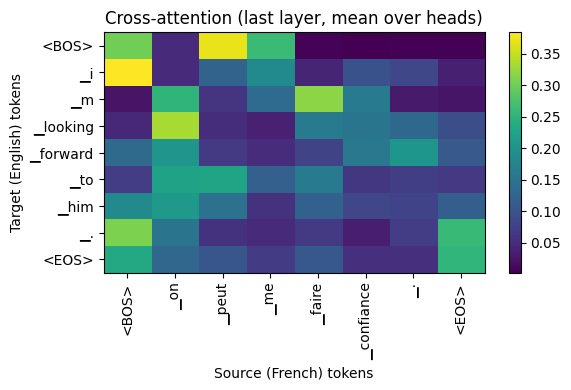

In [10]:
# 1) BLEU on the test set 
bleu_score = compute_bleu(test_fr, test_en, beam_size=4, max_len=cfg.max_seq_len)
print("BLEU score:", bleu_score)

# 2) Visualize cross-attention for one example
src_text = str(test_fr[0])
pred_text = translate_fr_to_en(src_text, beam_size=4, max_len=cfg.max_seq_len)
print("FR:", src_text)
print("EN (pred):", pred_text)

src_ids, src_padding_mask = _encode_src(src_text, max_len=cfg.max_seq_len)
pred_ids = beam_search_decode(model, src_ids=src_ids, src_padding_mask=src_padding_mask, beam_size=4, max_len=cfg.max_seq_len)
tgt_ids = torch.tensor(pred_ids, dtype=torch.long, device=model.device).unsqueeze(0)

attn = get_cross_attention_matrix(src_ids=src_ids, tgt_ids=tgt_ids, src_padding_mask=src_padding_mask)

# Drop the BOS row on the target side (usually not meaningful)
src_tokens = _pretty_tokens(fr_tok, src_ids.squeeze(0).tolist())
tgt_tokens = _pretty_tokens(en_tok, pred_ids)
plot_cross_attention(attn[1:, :], src_tokens=src_tokens, tgt_tokens=tgt_tokens[1:], title="Cross-attention (last layer, mean over heads)")